SHAP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

In [3]:
SEED = 42

import os
import random

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [4]:
DATA_PATH = "/kaggle/input/datasets/bepebdepd/x5-comp-hillclimb/train_2.csv"
# DATA_PATH = "train_2.csv"


df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(5))

shape: (485082, 24)
columns: ['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии', 'РТО']


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74209339.11


In [5]:
df.columns = df.columns.str.replace(',', '', regex=False)
df.columns

Index(['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия категориальный',
       'Торговая площадь категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший в час', 'Трафик авто в час',
       'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс',
       'Флаг алкогольной лицензии', 'РТО'],
      dtype='object')

In [6]:
mean_cols = [c for c in df.columns if "Среднее" in str(c)]
mean_cols

['Среднее количество промо товаров в чеке',
 'Среднее количество товаров в чеке',
 'Среднее количество отмен']

# Prepare

In [7]:
import numpy as np
import pandas as pd
import calendar

def create_features_for_month(df, target_year, target_month, inflation_dict=None):
    """
    Функция собирает обучающие или тестовые признаки для конкретного целевого месяца.
    Все признаки, связанные с РТО, рассчитываются в логарифмической шкале (log1p).
    """
    
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Торговая площадь категориальный',
        'Дата открытия категориальный', 'Количество домохозяйств', 'Количество касс',
        'Трафик пеший в час', 'Трафик авто в час',
        'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 
        'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)'
    ]

    base_df = df[static_cols].drop_duplicates(subset=['new_id']).copy()
    
    target_time_value = target_year * 12 + target_month
    history_before_target = df[(df['Год'] * 12 + df['Месяц']) < target_time_value].copy()
    
    metrics_to_agg = [
        'Среднее количество промо товаров в чеке',
        'Среднее количество товаров в чеке',
        'Среднее количество отмен'
    ]

    shop_profile = history_before_target.groupby('new_id')[metrics_to_agg].mean().reset_index()

    cols_to_keep = ['new_id'] + metrics_to_agg
    base_df = base_df.merge(shop_profile[cols_to_keep], on='new_id', how='left')

    for col in cols_to_keep:
        if col != 'new_id':
            base_df[col] = base_df[col].fillna(0)
    
    base_df['Регион_Город'] = base_df['Регион'].astype(str) + "_" + base_df['Населенный пункт'].astype(str)
    
    def get_historical_rto(shift_months):
        total_months = target_year * 12 + (target_month - 1) - shift_months
        hist_y = total_months // 12
        hist_m = (total_months % 12) + 1
        
        hist_slice = df[(df['Год'] == hist_y) & (df['Месяц'] == hist_m)][['new_id', 'РТО']].copy()
        hist_slice[f'log_rto_lag_{shift_months}'] = np.log1p(hist_slice['РТО'])
        return hist_slice[['new_id', f'log_rto_lag_{shift_months}']]

    base_df = base_df.merge(get_historical_rto(1), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(2), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(6), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(12), on='new_id', how='left')

    base_df['log_rto_yoy_diff'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_12']
    base_df['reg_rto_yoy_trend'] = base_df.groupby('Регион')['log_rto_yoy_diff'].transform('mean')

    region_lag1_mean = base_df.groupby('Регион')['log_rto_lag_1'].transform('mean') 
    base_df['log_rto_vs_region'] = base_df['log_rto_lag_1'] - region_lag1_mean

    history_before_target['log_РТО'] = np.log1p(history_before_target['РТО'])
    
    def get_rolling_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')['log_РТО'].agg(['mean', 'std']).reset_index()
        agg_df.columns = [
            'new_id', 
            f'log_rto_roll_{window_months}m_mean', 
            f'log_rto_roll_{window_months}m_std'
        ]
        return agg_df
    
    base_df = base_df.merge(get_rolling_stats(3), on='new_id', how='left')
    base_df = base_df.merge(get_rolling_stats(6), on='new_id', how='left')
    
    roll_cols = [c for c in base_df.columns if 'log_rto_' in c]
    # for c in roll_cols:
    #     base_df[c] = base_df[c].fillna(0)

    #(эквивалент деления: mean_3m / lag_1)
    base_df['log_rto_trend_3m'] = base_df['log_rto_roll_3m_mean'] - base_df['log_rto_lag_1']
    #(эквивалент деления: mean_6m / mean_3m)
    base_df['log_rto_trend_6m_vs_3m'] = base_df['log_rto_roll_6m_mean'] - base_df['log_rto_roll_3m_mean']
    base_df['log_rto_momentum'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_2']


    def get_rolling_other_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')[['Среднее количество промо товаров в чеке', 'Среднее количество отмен']].mean().reset_index()
        agg_df.columns = [
            'new_id', 
            f'promo_roll_{window_months}m_mean', 
            f'cancels_roll_{window_months}m_mean'
        ]
        return agg_df

    base_df = base_df.merge(get_rolling_other_stats(3), on='new_id', how='left')
    base_df['promo_roll_3m_mean'] = base_df['promo_roll_3m_mean'].fillna(0)
    base_df['cancels_roll_3m_mean'] = base_df['cancels_roll_3m_mean'].fillna(0)


    # Блок Отмен и Промо (Аномалии)
    base_df['cancels_anomaly'] = base_df['Среднее количество отмен'] - base_df['cancels_roll_3m_mean']
    base_df['promo_anomaly'] = base_df['Среднее количество промо товаров в чеке'] - base_df['promo_roll_3m_mean']
    base_df.drop(columns=['Среднее количество отмен', 'Среднее количество промо товаров в чеке'], inplace=True)

    
    rto_lag_1_linear = np.expm1(base_df['log_rto_lag_1'])
    base_df['log_rto_per_household'] = np.log1p(rto_lag_1_linear / (base_df['Количество домохозяйств'] + 1))
    base_df['traffic_per_household'] = base_df['Трафик пеший в час'] / (base_df['Количество домохозяйств'] + 1)



    base_df['traffic_per_cashbox'] = base_df['Трафик пеший в час'] / (base_df['Количество касс'] + 1)
    base_df['competitor_density'] = base_df['Продуктовые магазины (500 м)'] / (base_df['Количество домохозяйств'] + 1)


    base_df['Месяц_сезон'] = int(target_month)

    store_age = history_before_target.groupby('new_id').size().reset_index(name='store_age_months')
    base_df = base_df.merge(store_age, on='new_id', how='left')
    base_df['store_age_months'] = base_df['store_age_months'].fillna(0)

    
    abs_target_month = target_year * 12 + target_month - 1
    lag1_abs = abs_target_month - 1
    y_lag1 = lag1_abs // 12
    m_lag1 = (lag1_abs % 12) + 1

    def count_weekends(yr, mo):
        cal = calendar.Calendar()
        return sum(1 for d in cal.itermonthdays2(yr, mo) if d[0] != 0 and d[1] in (5, 6))

    target_weekends = count_weekends(target_year, target_month)
    lag1_weekends = count_weekends(y_lag1, m_lag1)
    
    base_df['weekends_ratio'] = target_weekends / (lag1_weekends + 1e-5)


    days_in_lag1_month = calendar.monthrange(y_lag1, m_lag1)[1]
    days_in_target_month = calendar.monthrange(target_year, target_month)[1]
    base_df['days_in_target_month'] = days_in_target_month
    base_df['expected_log_rto_base'] = np.log1p((rto_lag_1_linear / days_in_lag1_month) * days_in_target_month)
    base_df['month_days_ratio'] = days_in_target_month / days_in_lag1_month
    
    base_df['own_network_share'] = base_df['Пятерочки (500 м)'] / (base_df['Продуктовые магазины (500 м)'] + 1e-5)
    total_traffic = base_df['Трафик пеший в час'] + base_df['Трафик авто в час'] + 1e-5
    base_df['pedestrian_traffic_ratio'] = base_df['Трафик пеший в час'] / total_traffic
    base_df['poi_magnetism_index'] = (
        base_df['Маркетплейсы доставки постаматы (100 м)'] + 
        base_df['Медицинские уч. и аптеки (300 м)'] + 
        base_df['Школы (300 м)'] + 
        base_df['Остановки (300 м)'])
    base_df['reg_short_term_momentum'] = base_df.groupby('Регион')['log_rto_trend_3m'].transform('mean')


    # Какую часть чека в прошлом месяце составляли товары по акции?
    promo_share_lag1 = history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
        ].set_index('new_id')['Среднее количество промо товаров в чеке'] / (history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
    ].set_index('new_id')['Среднее количество товаров в чеке'] + 1e-5)
    base_df['promo_share_lag1'] = base_df['new_id'].map(promo_share_lag1).fillna(0)

    colleague_static = ['Численность населения']#, 'Флаг алкогольной лицензии'
    c_static_df = df[['new_id'] + colleague_static].drop_duplicates(subset=['new_id'])
    base_df = base_df.merge(c_static_df, on='new_id', how='left')
    
    # #------------------------------------
    # Общее количество всех POI (точек интереса) вокруг магазина
    # base_df['total_poi_around'] = (
    #     base_df['Маркетплейсы доставки постаматы (100 м)'] + 
    #     base_df['Медицинские уч. и аптеки (300 м)'] + 
    #     base_df['Школы (300 м)'] + 
    #     base_df['Остановки (300 м)'] +
    #     base_df['Продуктовые магазины (500 м)']
    # )
    # base_df['grocery_density_ratio'] = base_df['Продуктовые магазины (500 м)'] / (base_df['total_poi_around'] + 1e-5)
    
    # competitors_only = base_df['Продуктовые магазины (500 м)'] - base_df['Пятерочки (500 м)']
    # base_df['competitor_pressure'] = competitors_only / (base_df['Пятерочки (500 м)'] + 1e-5)
    # #------------------------------------

  
    #base_df.drop(columns=['Школы (300 м)', 'Пятерочки (500 м)'], inplace=True)# 'Населенный пункт',  Трафик_авто_в_час own_network_share, Маркетплейсы_доставки_постматы, cansels_anomaly, traffic_per_cashbox
    #'Медицинские уч. и аптеки (300 м)', 'Маркетплейсы доставки постаматы (100 м)', 
    base_df.drop(columns=['log_rto_roll_3m_mean', 'log_rto_roll_6m_mean', 'log_rto_lag_2'], inplace=True)

    return base_df

In [8]:
import pandas as pd
import numpy as np

all_months = []

unique_periods = df[['Год', 'Месяц']].drop_duplicates().sort_values(by=['Год',  'Месяц'])

for _, row in unique_periods.iterrows():
    year = int(row['Год'])
    month = int(row[ 'Месяц'])
    
    X_m = create_features_for_month(df, year, month)
    
    y_m = df[(df['Год'] == year) & (df[ 'Месяц'] == month)][['new_id', 'РТО']]
    # y_m = df[(df['Год'] == year) & (df['Месяц'] == month)][['new_id', 'РТО', 'РТО_nominal']]
    
    merged = X_m.merge(y_m, on='new_id', how='inner')
    merged['time_id'] = year * 100 + month # 202301, 202302 и т.д.
    
    all_months.append(merged)
    print(f"Собран {year}-{month:02d} | Строк: {len(merged)}")

master_df = pd.concat(all_months, ignore_index=True)

cat_features = [
    'Регион',  'Торговая площадь категориальный',
    'Дата открытия категориальный', 'Регион_Город', 'Месяц_сезон', 'Населенный пункт'#, 'Флаг алкогольной лицензии'#, #'Регион_Площадь', 'Регион_Алко'
]
for col in cat_features:
    master_df[col] = master_df[col].fillna('Missing').astype(str)

print(f"shape: {master_df.shape}")

Собран 2023-01 | Строк: 18657
Собран 2023-02 | Строк: 18657
Собран 2023-03 | Строк: 18657
Собран 2023-04 | Строк: 18657
Собран 2023-05 | Строк: 18657
Собран 2023-06 | Строк: 18657
Собран 2023-07 | Строк: 18657
Собран 2023-08 | Строк: 18657
Собран 2023-09 | Строк: 18657
Собран 2023-10 | Строк: 18657
Собран 2023-11 | Строк: 18657
Собран 2023-12 | Строк: 18657
Собран 2024-01 | Строк: 18657
Собран 2024-02 | Строк: 18657
Собран 2024-03 | Строк: 18657
Собран 2024-04 | Строк: 18657
Собран 2024-05 | Строк: 18657
Собран 2024-06 | Строк: 18657
Собран 2024-07 | Строк: 18657
Собран 2024-08 | Строк: 18657
Собран 2024-09 | Строк: 18657
Собран 2024-10 | Строк: 18657
Собран 2024-11 | Строк: 18657
Собран 2024-12 | Строк: 18657
Собран 2025-01 | Строк: 18657
Собран 2025-02 | Строк: 18657
shape: (485082, 50)


In [8]:
master_df.head(3)

,new_id,Регион,Населенный пункт,Торговая площадь категориальный,Дата открытия категориальный,Количество домохозяйств,Количество касс,Трафик пеший в час,Трафик авто в час,Маркетплейсы доставки постаматы (100 м),Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Среднее количество товаров в чеке,Регион_Город,log_rto_lag_1,log_rto_lag_6,log_rto_lag_12,log_rto_yoy_diff,reg_rto_yoy_trend,log_rto_vs_region,log_rto_roll_3m_std,log_rto_roll_6m_std,log_rto_trend_3m,log_rto_trend_6m_vs_3m,log_rto_momentum,promo_roll_3m_mean,cancels_roll_3m_mean,cancels_anomaly,promo_anomaly,log_rto_per_household,traffic_per_household,traffic_per_cashbox,competitor_density,Месяц_сезон,store_age_months,weekends_ratio,days_in_target_month,expected_log_rto_base,month_days_ratio,own_network_share,pedestrian_traffic_ratio,poi_magnetism_index,reg_short_term_momentum,promo_share_lag1,Численность населения,РТО,time_id
0,0,Ярославская обл,Ярославль г,Большой,Новый,3775,10,138,73,1,0,0,0,3,1,0.0,Ярославская обл_Ярославль г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.036547,12.545455,0.000794,1,0.0,0.999999,31,NaN,1.0,0.333332,0.654028,1,NaN,0.0,603883,74914754.22,202301
1,1,Челябинская обл,Магнитогорск г,Средний,Средний по возрасту,2627,8,143,443,2,0,1,5,4,1,0.0,Челябинская обл_Магнитогорск г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.054414,15.888889,0.001522,1,0.0,0.999999,31,NaN,1.0,0.249999,0.244027,8,NaN,0.0,355978,31205203.83,202301
2,2,Татарстан Респ,Казань г,Маленький,Средний по возрасту,10652,8,176,335,1,8,0,4,9,6,0.0,Татарстан Респ_Казань г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.016521,19.555556,0.000845,1,0.0,0.999999,31,NaN,1.0,0.666666,0.344423,13,NaN,0.0,1419953,59621632.75,202301


In [9]:
ts = master_df['time_id'].unique()
ts, len(ts)

(array([202301, 202302, 202303, 202304, 202305, 202306, 202307, 202308,
        202309, 202310, 202311, 202312, 202401, 202402, 202403, 202404,
        202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412,
        202501, 202502]),
 26)

In [10]:
DROP_COLS = ['new_id', 'РТО', 'time_id']

In [11]:
time_ids = sorted(master_df['time_id'].unique())
len(time_ids)

26

# Test pipeline

In [12]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
import gc

PRED_COLS_6MODEL = ['pred_cb_raw', 'pred_lgb_raw', 'pred_cb_m', 'pred_lgb_m', 'pred_cb_d', 'pred_lgb_d']
# Backward-compatible alias for old cells that may still reference the 4-model name.
PRED_COLS_4MODEL = ['pred_cb_m', 'pred_lgb_m', 'pred_cb_d', 'pred_lgb_d']


def run_cv_6model_ensemble(master_df, val_cnt, time_ids, cat_features, drop_cols, cb_params, lgbm_params):
    val_time_ids = time_ids[-val_cnt:]
    fold_scores = []
    oof_parts = []

    stored_cb_raw, stored_lgb_raw = [], []
    stored_cb_m, stored_lgb_m = [], []
    stored_cb_d, stored_lgb_d = [], []

    cb_raw_iters, lgb_raw_iters = [], []
    cb_m_iters, lgb_m_iters = [], []
    cb_d_iters, lgb_d_iters = [], []

    df_copy = master_df.copy()
    for col in cat_features:
        df_copy[col] = df_copy[col].astype(str).astype('category')

    for val_time in val_time_ids:
        print(f"=== Валидация на месяце: {val_time} ===")

        train_df = df_copy[df_copy['time_id'] < val_time].copy()
        val_df = df_copy[df_copy['time_id'] == val_time].copy()

        DROP_COLS_RAW = DROP_COLS
        DROP_COLS_MONTH = DROP_COLS + ['days_in_target_month']
        DROP_COLS_DAY = DROP_COLS

        X_train_raw = train_df.drop(columns=DROP_COLS_RAW)
        X_val_raw = val_df.drop(columns=DROP_COLS_RAW)

        X_train_m = train_df.drop(columns=DROP_COLS_MONTH)
        X_val_m = val_df.drop(columns=DROP_COLS_MONTH)

        X_train_d = train_df.drop(columns=DROP_COLS_DAY)
        X_val_d = val_df.drop(columns=DROP_COLS_DAY)

        y_train_raw = train_df['РТО']
        y_val_raw = val_df['РТО']

        y_train_log_raw = np.log1p(y_train_raw)
        y_val_log_raw = np.log1p(y_val_raw)

        y_train_log_month = np.log1p(y_train_raw)
        y_val_log_month = np.log1p(y_val_raw)

        y_train_log_day = np.log1p(y_train_raw / train_df['days_in_target_month'])
        y_val_log_day = np.log1p(y_val_raw / val_df['days_in_target_month'])

        # CatBoost (Raw month target, with days_in_target_month feature)
        pool_train_raw = Pool(X_train_raw, y_train_log_raw, cat_features=cat_features)
        pool_val_raw = Pool(X_val_raw, y_val_log_raw, cat_features=cat_features)
        model_cb_raw = CatBoostRegressor(**cb_params)
        model_cb_raw.fit(pool_train_raw, eval_set=pool_val_raw, use_best_model=True, verbose=False)

        best_iter_cb_raw = model_cb_raw.get_best_iteration()
        cb_raw_iters.append(best_iter_cb_raw)

        preds_log_cb_raw = model_cb_raw.predict(X_val_raw)
        preds_raw_cb_raw = np.expm1(preds_log_cb_raw)
        stored_cb_raw.append(model_cb_raw)

        # LightGBM (Raw month target, with days_in_target_month feature)
        model_lgb_raw = lgb.LGBMRegressor(**lgbm_params)
        model_lgb_raw.fit(
            X_train_raw,
            y_train_log_raw,
            eval_set=[(X_val_raw, y_val_log_raw)],
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(300, verbose=False)]
        )

        best_iter_lgb_raw = model_lgb_raw.best_iteration_
        lgb_raw_iters.append(best_iter_lgb_raw)

        preds_log_lgb_raw = model_lgb_raw.predict(X_val_raw)
        preds_raw_lgb_raw = np.expm1(preds_log_lgb_raw)
        stored_lgb_raw.append(model_lgb_raw)

        # CatBoost (Month, without days_in_target_month feature)
        pool_train_m = Pool(X_train_m, y_train_log_month, cat_features=cat_features)
        pool_val_m = Pool(X_val_m, y_val_log_month, cat_features=cat_features)
        model_cb_m = CatBoostRegressor(**cb_params)
        model_cb_m.fit(pool_train_m, eval_set=pool_val_m, use_best_model=True, verbose=False)

        best_iter_cb_m = model_cb_m.get_best_iteration()
        cb_m_iters.append(best_iter_cb_m)

        preds_log_cb_m = model_cb_m.predict(X_val_m)
        preds_raw_cb_m = np.expm1(preds_log_cb_m)
        stored_cb_m.append(model_cb_m)

        # LightGBM (Month, without days_in_target_month feature)
        model_lgb_m = lgb.LGBMRegressor(**lgbm_params)
        model_lgb_m.fit(
            X_train_m,
            y_train_log_month,
            eval_set=[(X_val_m, y_val_log_month)],
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(300, verbose=False)]
        )

        best_iter_lgb_m = model_lgb_m.best_iteration_
        lgb_m_iters.append(best_iter_lgb_m)

        preds_log_lgb_m = model_lgb_m.predict(X_val_m)
        preds_raw_lgb_m = np.expm1(preds_log_lgb_m)
        stored_lgb_m.append(model_lgb_m)

        # CatBoost (Day)
        pool_train_day = Pool(X_train_d, y_train_log_day, cat_features=cat_features)
        pool_val_day = Pool(X_val_d, y_val_log_day, cat_features=cat_features)
        model_cb_d = CatBoostRegressor(**cb_params)
        model_cb_d.fit(pool_train_day, eval_set=pool_val_day, use_best_model=True, verbose=False)

        best_iter_cb_d = model_cb_d.get_best_iteration()
        cb_d_iters.append(best_iter_cb_d)

        preds_log_cb_d = model_cb_d.predict(X_val_d)
        preds_raw_cb_d = np.expm1(preds_log_cb_d) * val_df['days_in_target_month']
        stored_cb_d.append(model_cb_d)

        # LightGBM (Day)
        model_lgb_d = lgb.LGBMRegressor(**lgbm_params)
        model_lgb_d.fit(
            X_train_d,
            y_train_log_day,
            eval_set=[(X_val_d, y_val_log_day)],
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(300, verbose=False)]
        )

        best_iter_lgb_d = model_lgb_d.best_iteration_
        lgb_d_iters.append(best_iter_lgb_d)

        preds_log_lgb_d = model_lgb_d.predict(X_val_d)
        preds_raw_lgb_d = np.expm1(preds_log_lgb_d) * val_df['days_in_target_month']
        stored_lgb_d.append(model_lgb_d)

        # Simple 6-model blend for baseline fold score. HillClimbing below learns better weights from OOF.
        final_preds_raw = (
            preds_raw_cb_raw + preds_raw_lgb_raw +
            preds_raw_cb_m + preds_raw_lgb_m +
            preds_raw_cb_d + preds_raw_lgb_d
        ) / 6.0
        final_preds_raw = np.clip(final_preds_raw, 0, None)

        oof_parts.append(pd.DataFrame({
            'new_id': val_df['new_id'].to_numpy(),
            'time_id': val_df['time_id'].to_numpy(),
            'y_true': y_val_raw.to_numpy(),
            'pred_cb_raw': preds_raw_cb_raw,
            'pred_lgb_raw': preds_raw_lgb_raw,
            'pred_cb_m': preds_raw_cb_m,
            'pred_lgb_m': preds_raw_lgb_m,
            'pred_cb_d': preds_raw_cb_d,
            'pred_lgb_d': preds_raw_lgb_d,
        }))

        mape_cb_raw = mean_absolute_percentage_error(y_val_raw, preds_raw_cb_raw) * 100
        mape_lgb_raw = mean_absolute_percentage_error(y_val_raw, preds_raw_lgb_raw) * 100
        mape_cb_m = mean_absolute_percentage_error(y_val_raw, preds_raw_cb_m) * 100
        mape_lgb_m = mean_absolute_percentage_error(y_val_raw, preds_raw_lgb_m) * 100
        mape_cb_d = mean_absolute_percentage_error(y_val_raw, preds_raw_cb_d) * 100
        mape_lgb_d = mean_absolute_percentage_error(y_val_raw, preds_raw_lgb_d) * 100

        fold_mape = mean_absolute_percentage_error(y_val_raw, final_preds_raw) * 100
        fold_scores.append(fold_mape / 100)

        print(f"MAPE Raw-models   -> CB: {mape_cb_raw:.3f}% (best iter: {best_iter_cb_raw}) | LGBM: {mape_lgb_raw:.3f}% (best iter: {best_iter_lgb_raw})")
        print(f"MAPE Month-models -> CB: {mape_cb_m:.3f}% (best iter: {best_iter_cb_m}) | LGBM: {mape_lgb_m:.3f}% (best iter: {best_iter_lgb_m})")
        print(f"MAPE Day-models   -> CB: {mape_cb_d:.3f}% (best iter: {best_iter_cb_d}) | LGBM: {mape_lgb_d:.3f}% (best iter: {best_iter_lgb_d})")
        print(f"--> ФИНАЛЬНЫЙ АНСАМБЛЬ 6 МОДЕЛЕЙ MAPE: {fold_mape:.3f}%\n")

    print("="*50)
    print(f"Средний MAPE ансамбля по фолдам: {np.mean(fold_scores)*100:.3f}%")
    print("РЕКОМЕНДУЕМЫЕ ИТЕРАЦИИ ДЛЯ ФИНАЛЬНОГО ОБУЧЕНИЯ (ОКРУГЛЕННОЕ СРЕДНЕЕ):")
    print(f" -> CatBoost Raw:   {int(np.mean(cb_raw_iters))}")
    print(f" -> LightGBM Raw:   {int(np.mean(lgb_raw_iters))}")
    print(f" -> CatBoost Month: {int(np.mean(cb_m_iters))}")
    print(f" -> LightGBM Month: {int(np.mean(lgb_m_iters))}")
    print(f" -> CatBoost Day:   {int(np.mean(cb_d_iters))}")
    print(f" -> LightGBM Day:   {int(np.mean(lgb_d_iters))}")
    print("="*50)

    oof_predictions = pd.concat(oof_parts, ignore_index=True)
    return (
        stored_cb_raw, stored_lgb_raw,
        stored_cb_m, stored_lgb_m,
        stored_cb_d, stored_lgb_d,
        fold_scores,
        oof_predictions,
    )


def run_cv_4model_ensemble(master_df, val_cnt, time_ids, cat_features, drop_cols, cb_params, lgbm_params):
    """Compatibility wrapper: returns the 6-model CV outputs."""
    return run_cv_6model_ensemble(master_df, val_cnt, time_ids, cat_features, drop_cols, cb_params, lgbm_params)


def _weighted_mape(y_true, y_pred, sample_weight=None):
    return mean_absolute_percentage_error(y_true, y_pred, sample_weight=sample_weight)


def _hill_climb_weights(fit_df, pred_cols=PRED_COLS_6MODEL, alpha_grid=None,
                        max_steps=100, min_improvement=1e-7, sample_weight=None,
                        title='Hill climbing'):
    if alpha_grid is None:
        alpha_grid = np.round(np.arange(0.01, 0.501, 0.01), 2)

    y_fit = fit_df['y_true'].to_numpy()
    sample_weight = None if sample_weight is None else np.asarray(sample_weight, dtype=float)

    single_scores = {
        col: _weighted_mape(y_fit, fit_df[col].to_numpy(), sample_weight=sample_weight)
        for col in pred_cols
    }
    start_col = min(single_scores, key=single_scores.get)
    current_pred = fit_df[start_col].to_numpy().copy()
    weights = {col: 0.0 for col in pred_cols}
    weights[start_col] = 1.0
    best_score = single_scores[start_col]
    history = [{
        'step': 0,
        'added_model': start_col,
        'alpha': 1.0,
        'fit_mape': best_score,
        **{f'weight_{col}': weights[col] for col in pred_cols}
    }]

    print(f"{title}")
    print(f"Start model: {start_col} | fit MAPE: {best_score * 100:.4f}%")

    for step in range(1, max_steps + 1):
        best_candidate = None
        best_candidate_pred = None
        best_candidate_score = best_score

        for col in pred_cols:
            candidate_pred = fit_df[col].to_numpy()
            for alpha in alpha_grid:
                mixed_pred = (1.0 - alpha) * current_pred + alpha * candidate_pred
                score = _weighted_mape(y_fit, mixed_pred, sample_weight=sample_weight)
                if score < best_candidate_score:
                    best_candidate_score = score
                    best_candidate = (col, float(alpha))
                    best_candidate_pred = mixed_pred

        if best_candidate is None or (best_score - best_candidate_score) < min_improvement:
            print(f"Stop at step {step - 1} | fit MAPE: {best_score * 100:.4f}%")
            break

        col, alpha = best_candidate
        current_pred = best_candidate_pred
        for key in weights:
            weights[key] *= (1.0 - alpha)
        weights[col] += alpha
        best_score = best_candidate_score
        history.append({
            'step': step,
            'added_model': col,
            'alpha': alpha,
            'fit_mape': best_score,
            **{f'weight_{key}': weights[key] for key in pred_cols}
        })

        print(f"Step {step:02d}: add {col} alpha={alpha:.2f} | fit MAPE: {best_score * 100:.4f}%")

    weights = {col: float(w) for col, w in weights.items()}
    weights_sum = sum(weights.values())
    weights = {col: w / weights_sum for col, w in weights.items()}
    fit_pred = sum(weights[col] * fit_df[col].to_numpy() for col in pred_cols)
    fit_mape = _weighted_mape(y_fit, fit_pred, sample_weight=sample_weight)
    fit_mape_unweighted = _weighted_mape(y_fit, fit_pred)

    print("Final hill-climb weights:")
    for col, weight in weights.items():
        print(f" -> {col}: {weight:.5f}")
    print(f"Fit MAPE with hill-climb weights: {fit_mape * 100:.4f}%")
    if sample_weight is not None:
        print(f"Fit unweighted MAPE with the same weights: {fit_mape_unweighted * 100:.4f}%")

    return weights, pd.DataFrame(history), {
        'fit_mape': fit_mape,
        'fit_mape_unweighted': fit_mape_unweighted,
    }


def hill_climb_weights_train_check(oof_df, pred_cols=PRED_COLS_6MODEL, train_months_cnt=3,
                                   alpha_grid=None, max_steps=100, min_improvement=1e-7):
    """
    Подбирает веса на первых train_months_cnt OOF-месяцах и проверяет их на следующем месяце.
    Стартует с лучшей одиночной модели на train-части, затем итеративно добавляет модели.
    """
    val_months = sorted(oof_df['time_id'].unique())
    if len(val_months) <= train_months_cnt:
        raise ValueError("Для train/check режима нужен хотя бы один check-месяц после train-месяцев")

    train_months = val_months[:train_months_cnt]
    check_month = val_months[train_months_cnt]
    train_df = oof_df[oof_df['time_id'].isin(train_months)].copy()
    check_df = oof_df[oof_df['time_id'] == check_month].copy()

    weights, history, report = _hill_climb_weights(
        train_df,
        pred_cols=pred_cols,
        alpha_grid=alpha_grid,
        max_steps=max_steps,
        min_improvement=min_improvement,
        title=f"Hill climbing train months: {train_months} | check month: {check_month}"
    )

    y_check = check_df['y_true'].to_numpy()
    check_pred = sum(weights[col] * check_df[col].to_numpy() for col in pred_cols)
    check_mape = mean_absolute_percentage_error(y_check, check_pred)
    print(f"Check MAPE with hill-climb weights: {check_mape * 100:.4f}%")

    report.update({
        'mode': 'train_check',
        'train_months': train_months,
        'check_month': check_month,
        'train_mape': report['fit_mape'],
        'check_mape': check_mape,
    })
    return weights, history, report


def hill_climb_weights_global(oof_df, pred_cols=PRED_COLS_6MODEL,
                              alpha_grid=None, max_steps=100, min_improvement=1e-7):
    """
    Подбирает веса на всех доступных OOF-месяцах без отдельного check-месяца.
    Этот режим можно использовать как финальную настройку после выбора подхода на train/check.
    """
    val_months = sorted(oof_df['time_id'].unique())
    weights, history, report = _hill_climb_weights(
        oof_df.copy(),
        pred_cols=pred_cols,
        alpha_grid=alpha_grid,
        max_steps=max_steps,
        min_improvement=min_improvement,
        title=f"Hill climbing global months: {val_months}"
    )
    report.update({
        'mode': 'global',
        'fit_months': val_months,
        'global_mape': report['fit_mape'],
    })
    return weights, history, report


def hill_climb_weights_recent_weighted(oof_df, pred_cols=PRED_COLS_6MODEL, month_weights=None,
                                       alpha_grid=None, max_steps=100, min_improvement=1e-7):
    """
    Подбирает веса на всех OOF-месяцах, но с большим весом для более свежих месяцев.
    По умолчанию для 4 месяцев используются веса 1.0, 1.0, 1.2, 1.5.
    """
    val_months = sorted(oof_df['time_id'].unique())
    if month_weights is None:
        if len(val_months) == 4:
            month_weights = dict(zip(val_months, [1.0, 1.0, 1.2, 1.5]))
        else:
            month_weights = dict(zip(val_months, np.linspace(1.0, 1.5, len(val_months))))
    elif not isinstance(month_weights, dict):
        if len(month_weights) != len(val_months):
            raise ValueError("month_weights должен иметь такую же длину, как число OOF-месяцев")
        month_weights = dict(zip(val_months, month_weights))

    fit_df = oof_df.copy()
    sample_weight = fit_df['time_id'].map(month_weights).to_numpy(dtype=float)

    weights, history, report = _hill_climb_weights(
        fit_df,
        pred_cols=pred_cols,
        alpha_grid=alpha_grid,
        max_steps=max_steps,
        min_improvement=min_improvement,
        sample_weight=sample_weight,
        title=f"Hill climbing recent-weighted months: {month_weights}"
    )
    report.update({
        'mode': 'recent_weighted',
        'month_weights': month_weights,
        'weighted_mape': report['fit_mape'],
        'unweighted_mape': report['fit_mape_unweighted'],
    })
    return weights, history, report


In [13]:
import logging
import warnings
import lightgbm as lgb

warnings.filterwarnings("ignore")

logger = logging.getLogger("lightgbm")
logger.setLevel(logging.ERROR)
for handler in logger.handlers[:]:
    logger.removeHandler(handler)

lgb.register_logger(logging.getLogger("dummy"))

## Optimize MAE

In [14]:
cb_params = {
    'iterations': 3500,
    'learning_rate': 0.067,
    'depth': 8,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 4.6,
    'task_type': 'GPU'
}

lgbm_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.088,
    'n_estimators': 3500,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': 95,
    'max_depth': 7,
    'min_child_samples': 100,
    'colsample_bytree': 1,
    'subsample': 0.525
}


time_ids = sorted(master_df['time_id'].unique())

models_cb_raw, models_lgb_raw, models_cb_m, models_lgb_m, models_cb_d, models_lgb_d, scores_ensemble, oof_6model = run_cv_6model_ensemble(
    master_df=master_df,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_params=cb_params,
    lgbm_params=lgbm_params
)

HC_WEIGHTS_TRAIN_CHECK, hc_history_train_check, hc_report_train_check = hill_climb_weights_train_check(
    oof_6model,
    pred_cols=PRED_COLS_6MODEL,
    train_months_cnt=3
)

HC_WEIGHTS_GLOBAL, hc_history_global, hc_report_global = hill_climb_weights_global(
    oof_6model,
    pred_cols=PRED_COLS_6MODEL
)

HC_WEIGHTS_RECENT, hc_history_recent, hc_report_recent = hill_climb_weights_recent_weighted(
    oof_6model,
    pred_cols=PRED_COLS_6MODEL
)

# По умолчанию финальный submit использует самый честный режим: train на первых 3 месяцах, check на 4-м.
HC_WEIGHTS = HC_WEIGHTS_TRAIN_CHECK
hc_history = hc_history_train_check
hc_report = hc_report_train_check


=== Валидация на месяце: 202411 ===
MAPE Raw-models   -> CB: 3.717% (best iter: 2048) | LGBM: 3.764% (best iter: 287)
MAPE Month-models -> CB: 3.741% (best iter: 2594) | LGBM: 3.764% (best iter: 287)
MAPE Day-models   -> CB: 3.689% (best iter: 681) | LGBM: 3.778% (best iter: 316)
--> ФИНАЛЬНЫЙ АНСАМБЛЬ 6 МОДЕЛЕЙ MAPE: 3.606%

=== Валидация на месяце: 202412 ===
MAPE Raw-models   -> CB: 3.936% (best iter: 3499) | LGBM: 3.956% (best iter: 3494)
MAPE Month-models -> CB: 4.229% (best iter: 2934) | LGBM: 3.956% (best iter: 3494)
MAPE Day-models   -> CB: 3.863% (best iter: 3499) | LGBM: 4.011% (best iter: 3500)
--> ФИНАЛЬНЫЙ АНСАМБЛЬ 6 МОДЕЛЕЙ MAPE: 3.754%

=== Валидация на месяце: 202501 ===
MAPE Raw-models   -> CB: 4.162% (best iter: 3357) | LGBM: 4.477% (best iter: 3469)
MAPE Month-models -> CB: 4.099% (best iter: 2436) | LGBM: 4.480% (best iter: 3469)
MAPE Day-models   -> CB: 4.127% (best iter: 3483) | LGBM: 4.731% (best iter: 3346)
--> ФИНАЛЬНЫЙ АНСАМБЛЬ 6 МОДЕЛЕЙ MAPE: 3.965%

=== Вали

In [ ]:
cb_params = {
    'iterations': 3000,
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU'
}

lgbm_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 4000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': 45,
    'max_depth': 7,
    'min_child_samples': 70,
    'colsample_bytree': 1, #0.7,
    'subsample': 1 #0.8
}

time_ids = sorted(master_df['time_id'].unique())

models_cb_raw, models_lgb_raw, models_cb_m, models_lgb_m, models_cb_d, models_lgb_d, scores_ensemble, oof_6model = run_cv_6model_ensemble(
    master_df=master_df,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_params=cb_params,
    lgbm_params=lgbm_params
)

HC_WEIGHTS_TRAIN_CHECK, hc_history_train_check, hc_report_train_check = hill_climb_weights_train_check(
    oof_6model,
    pred_cols=PRED_COLS_6MODEL,
    train_months_cnt=3
)

HC_WEIGHTS_GLOBAL, hc_history_global, hc_report_global = hill_climb_weights_global(
    oof_6model,
    pred_cols=PRED_COLS_6MODEL
)

HC_WEIGHTS_RECENT, hc_history_recent, hc_report_recent = hill_climb_weights_recent_weighted(
    oof_6model,
    pred_cols=PRED_COLS_6MODEL
)

# По умолчанию финальный submit использует самый честный режим: train на первых 3 месяцах, check на 4-м.
HC_WEIGHTS = HC_WEIGHTS_TRAIN_CHECK
hc_history = hc_history_train_check
hc_report = hc_report_train_check


In [16]:
HC_WEIGHTS = HC_WEIGHTS_GLOBAL
hc_history = hc_history_global
hc_report = hc_report_global


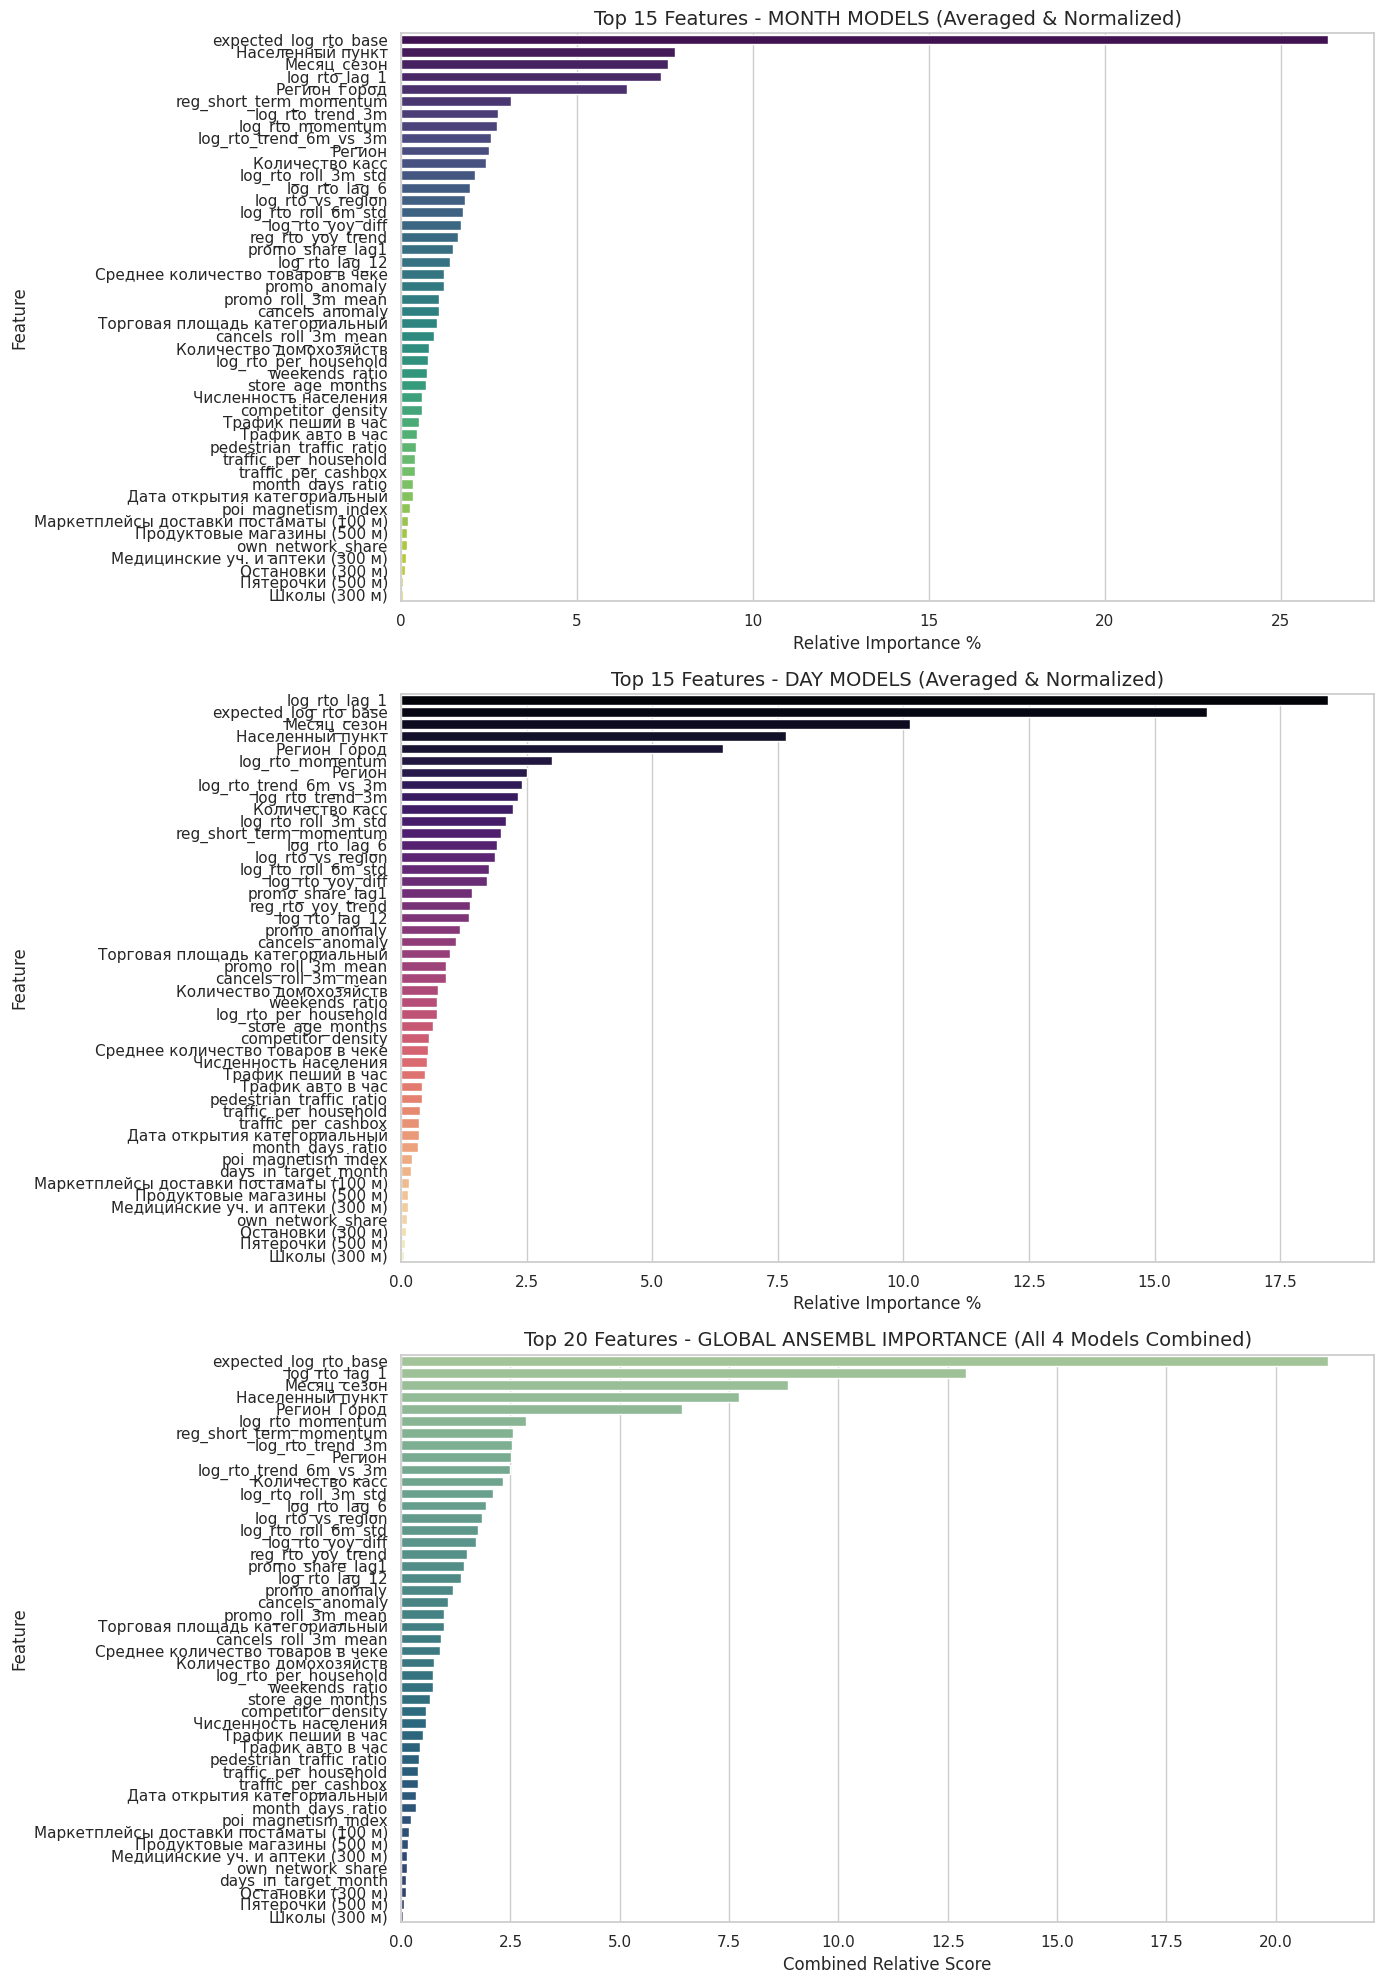

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DROP_COLS_MONTH = DROP_COLS + ['days_in_target_month'] 
DROP_COLS_DAY = DROP_COLS  

features_m = [col for col in master_df.columns if col not in DROP_COLS_MONTH]
features_d = [col for col in master_df.columns if col not in DROP_COLS_DAY]

def get_avg_importance(models, feature_names, is_catboost=True):
    importances = np.zeros(len(feature_names))
    for model in models:
        importances += model.get_feature_importance() if is_catboost else model.feature_importances_
    return importances / len(models)


cb_m_imp = get_avg_importance(models_cb_m, features_m, is_catboost=True)
lgb_m_imp = get_avg_importance(models_lgb_m, features_m, is_catboost=False)


cb_m_imp = 100 * (cb_m_imp / cb_m_imp.sum())
lgb_m_imp = 100 * (lgb_m_imp / lgb_m_imp.sum())

df_month = pd.DataFrame({'Feature': features_m, 'CatBoost_M': cb_m_imp, 'LightGBM_M': lgb_m_imp})
df_month['Total_Month_Importance'] = (df_month['CatBoost_M'] + df_month['LightGBM_M']) / 2
df_month = df_month.sort_values(by='Total_Month_Importance', ascending=False)


cb_day_imp = get_avg_importance(models_cb_d, features_d, is_catboost=True)
lgb_day_imp = get_avg_importance(models_lgb_d, features_d, is_catboost=False)

cb_day_imp = 100 * (cb_day_imp / cb_day_imp.sum())
lgb_day_imp = 100 * (lgb_day_imp / lgb_day_imp.sum())

df_day = pd.DataFrame({'Feature': features_d, 'CatBoost_D': cb_day_imp, 'LightGBM_D': lgb_day_imp})
df_day['Total_Day_Importance'] = (df_day['CatBoost_D'] + df_day['LightGBM_D']) / 2
df_day = df_day.sort_values(by='Total_Day_Importance', ascending=False)


df_global = pd.merge(
    df_month[['Feature', 'Total_Month_Importance']], 
    df_day[['Feature', 'Total_Day_Importance']], 
    on='Feature', how='outer'
).fillna(0)

df_global['Global_Importance'] = (df_global['Total_Month_Importance'] + df_global['Total_Day_Importance']) / 2
df_global = df_global.sort_values(by='Global_Importance', ascending=False)


fig, axes = plt.subplots(3, 1, figsize=(14, 20))


sns.barplot(data=df_month, x='Total_Month_Importance', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Features - MONTH MODELS (Averaged & Normalized)', fontsize=14)
axes[0].set_xlabel('Relative Importance %')


sns.barplot(data=df_day, x='Total_Day_Importance', y='Feature', ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Features - DAY MODELS (Averaged & Normalized)', fontsize=14)
axes[1].set_xlabel('Relative Importance %')


sns.barplot(data=df_global, x='Global_Importance', y='Feature', ax=axes[2], palette='crest')
axes[2].set_title('Top 20 Features - GLOBAL ANSEMBL IMPORTANCE (All 4 Models Combined)', fontsize=14)
axes[2].set_xlabel('Combined Relative Score')

plt.tight_layout()
plt.show()

# Optuna

In [ ]:
import optuna
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
import gc


df_optuna = master_df.copy()
for col in cat_features:
    df_optuna[col] = df_optuna[col].astype(str).astype('category')

def objective(trial):
    cb_params = {
        'iterations': 3500,
        'learning_rate': trial.suggest_float('cb_lr', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('cb_depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('cb_l2', 1, 15),
        'loss_function': 'MAE', #RMSE
        'eval_metric': 'MAE', #RMSE
        'random_seed': 42,
        'od_type': 'Iter',
        'od_wait': 200,
        'verbose': 0, 
        'task_type': 'GPU'
    }

    lgbm_params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': 3500,
        'learning_rate': trial.suggest_float('lgb_lr', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('lgb_leaves', 20, 150),
        'max_depth': -1, #trial.suggest_int('lgb_depth', 4, 10), #
        'min_child_samples': trial.suggest_int('lgb_min_child', 20, 100),
        'colsample_bytree': trial.suggest_float('lgb_colsample', 0.5, 1.0),
        'subsample': trial.suggest_float('lgb_subsample', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
        'device': 'cpu'
    }

    val_cnt = 4
    val_time_ids = time_ids[-val_cnt:]
    fold_scores = []

    for val_time in val_time_ids:
        train_df = df_optuna[df_optuna['time_id'] < val_time]
        val_df = df_optuna[df_optuna['time_id'] == val_time]

        X_train, y_train_raw = train_df.drop(columns=DROP_COLS), train_df['РТО']
        X_val, y_val_raw = val_df.drop(columns=DROP_COLS), val_df['РТО']

        y_train_log = np.log1p(y_train_raw)
        y_val_log = np.log1p(y_val_raw)


        train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
        val_pool = Pool(X_val, y_val_log, cat_features=cat_features)
        model_cb = CatBoostRegressor(**cb_params)
        model_cb.fit(train_pool, eval_set=val_pool, verbose=False)
        preds_log_cb = model_cb.predict(X_val)


        model_lgb = lgb.LGBMRegressor(**lgbm_params)
        model_lgb.fit(X_train, y_train_log, 
                      categorical_feature=cat_features, eval_set=[(X_val, y_val_log)], 
                      callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)])
        preds_log_lgb = model_lgb.predict(X_val)


        preds_log_ensemble = (preds_log_cb + preds_log_lgb) / 2.0
        preds_raw = np.clip(np.expm1(preds_log_ensemble), 0, None)
        
        fold_mape = mean_absolute_percentage_error(y_val_raw, preds_raw) * 100
        fold_scores.append(fold_mape)


        cb_trees = model_cb.get_best_iteration()
        lgb_trees = model_lgb.best_iteration_
        print(f">> Месяц {val_time} | Остановка CB: {cb_trees} итераций | LGBM: {lgb_trees} итераций | Ансамбль MAPE: {fold_mape:.3f}%")

    del train_df, val_df, X_train, X_val
    gc.collect()


    return np.mean(fold_scores)


In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший MAPE: {study.best_value * 100:.3f}%")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-05-27 18:29:24,738] A new study created in memory with name: no-name-ab28e0e7-ea1c-4170-b418-fe75999e97a3


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-27 18:43:11,428] Trial 0 finished with value: 0.03973187307973055 and parameters: {'cb_lr': 0.018162138265968047, 'cb_depth': 5, 'cb_l2': 6.345895694896618, 'lgb_lr': 0.05123462634362668, 'lgb_leaves': 64, 'lgb_depth': 10, 'lgb_min_child': 45, 'lgb_colsample': 0.6969724742971488, 'lgb_subsample': 0.6927946076298909}. Best is trial 0 with value: 0.03973187307973055.
[I 2026-05-27 18:58:02,322] Trial 1 finished with value: 0.040164850607488416 and parameters: {'cb_lr': 0.08468698295252318, 'cb_depth': 6, 'cb_l2': 4.650477185636273, 'lgb_lr': 0.09317751927261536, 'lgb_leaves': 73, 'lgb_depth': 9, 'lgb_min_child': 86, 'lgb_colsample': 0.5707067357137063, 'lgb_subsample': 0.7883313205869169}. Best is trial 0 with value: 0.03973187307973055.
[I 2026-05-27 19:12:23,641] Trial 2 finished with value: 0.03952848280165665 and parameters: {'cb_lr': 0.0605877036398026, 'cb_depth': 6, 'cb_l2': 2.5835356506430363, 'lgb_lr': 0.04995652474084309, 'lgb_leaves': 20, 'lgb_depth': 9, 'lgb_min_ch

KeyboardInterrupt: 

# Submit

In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool


cb_params = {
    'learning_rate': 0.067,
    'depth': 8,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': 500,
    'l2_leaf_reg': 4.6,
    'task_type': 'GPU'
}

lgbm_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.088,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'num_leaves': 95,
    'max_depth': 7,
    'min_child_samples': 100,
    'colsample_bytree': 1,
    'subsample': 0.525
}


def _avg_best_iter(history_models, fallback):
    values = []
    for model in history_models:
        if hasattr(model, 'get_best_iteration'):
            value = model.get_best_iteration()
        else:
            value = getattr(model, 'best_iteration_', None)
        if value is not None and value > 0:
            values.append(value)
    return int(np.mean(values) * 1.1) if values else fallback


DROP_COLS_RAW = DROP_COLS
DROP_COLS_MONTH = DROP_COLS + ['days_in_target_month']
DROP_COLS_DAY = DROP_COLS

X_train_raw = master_df.drop(columns=DROP_COLS_RAW).copy()
X_train_m = master_df.drop(columns=DROP_COLS_MONTH).copy()
X_train_d = master_df.drop(columns=DROP_COLS_DAY).copy()

for col in cat_features:
    X_train_raw[col] = X_train_raw[col].astype(str).astype('category')
    X_train_m[col] = X_train_m[col].astype(str).astype('category')
    X_train_d[col] = X_train_d[col].astype(str).astype('category')

y_train_raw_log = np.log1p(master_df['РТО'])
y_train_month_log = np.log1p(master_df['РТО'])
y_train_day_log = np.log1p(master_df['РТО'] / master_df['days_in_target_month'])

# raw/month target with days_in_target_month as a feature
print("Обучаем финальный CatBoost (Raw)...")
cb_params_raw = cb_params.copy()
cb_params_raw['iterations'] = _avg_best_iter(globals().get('models_cb_raw', []), int(2758 * 1.1))

pool_train_raw = Pool(X_train_raw, y_train_raw_log, cat_features=cat_features)
final_cb_raw = CatBoostRegressor(**cb_params_raw)
final_cb_raw.fit(pool_train_raw)

print("Обучаем финальный LightGBM (Raw)...")
lgbm_params_raw = lgbm_params.copy()
lgbm_params_raw['n_estimators'] = _avg_best_iter(globals().get('models_lgb_raw', []), int(2430 * 1.1))

final_lgb_raw = lgb.LGBMRegressor(**lgbm_params_raw)
final_lgb_raw.fit(X_train_raw, y_train_raw_log, categorical_feature=cat_features)

# month without days_in_target_month
print("\nОбучаем финальный CatBoost (Month)...")
cb_params_m = cb_params.copy()
cb_params_m['iterations'] = _avg_best_iter(globals().get('models_cb_m', []), int(2758 * 1.1))

pool_train_m = Pool(X_train_m, y_train_month_log, cat_features=cat_features)
final_cb_m = CatBoostRegressor(**cb_params_m)
final_cb_m.fit(pool_train_m)

print("Обучаем финальный LightGBM (Month)...")
lgbm_params_m = lgbm_params.copy()
lgbm_params_m['n_estimators'] = _avg_best_iter(globals().get('models_lgb_m', []), int(2430 * 1.1))

final_lgb_m = lgb.LGBMRegressor(**lgbm_params_m)
final_lgb_m.fit(X_train_m, y_train_month_log, categorical_feature=cat_features)

# day
print("\nОбучаем финальный CatBoost (Day)...")
cb_params_d = cb_params.copy()
cb_params_d['iterations'] = _avg_best_iter(globals().get('models_cb_d', []), int(2080 * 1.1))

pool_train_d = Pool(X_train_d, y_train_day_log, cat_features=cat_features)
final_cb_d = CatBoostRegressor(**cb_params_d)
final_cb_d.fit(pool_train_d)

print("Обучаем финальный LightGBM (Day)...")
lgbm_params_d = lgbm_params.copy()
lgbm_params_d['n_estimators'] = _avg_best_iter(globals().get('models_lgb_d', []), int(2467 * 1.1))

final_lgb_d = lgb.LGBMRegressor(**lgbm_params_d)
final_lgb_d.fit(X_train_d, y_train_day_log, categorical_feature=cat_features)


target_year = 2025
target_month = 3
print(f"\nГенерируем признаки для теста: {target_year}-{target_month:02d}...")
test_df = create_features_for_month(df, target_year, target_month)

for col in cat_features:
    test_df[col] = test_df[col].fillna('Missing').astype(str).astype('category')

submit_ids = test_df['new_id']

X_test_raw = test_df.drop(columns=DROP_COLS_RAW, errors='ignore')[X_train_raw.columns]
X_test_m = test_df.drop(columns=DROP_COLS_MONTH, errors='ignore')[X_train_m.columns]
X_test_d = test_df.drop(columns=DROP_COLS_DAY, errors='ignore')[X_train_d.columns]

print("Собираем прогнозы...")

preds_raw_cb_raw = np.expm1(final_cb_raw.predict(X_test_raw))
preds_raw_lgb_raw = np.expm1(final_lgb_raw.predict(X_test_raw))

preds_raw_cb_m = np.expm1(final_cb_m.predict(X_test_m))
preds_raw_lgb_m = np.expm1(final_lgb_m.predict(X_test_m))

days_in_march = test_df['days_in_target_month']
preds_raw_cb_d = np.expm1(final_cb_d.predict(X_test_d)) * days_in_march
preds_raw_lgb_d = np.expm1(final_lgb_d.predict(X_test_d)) * days_in_march

print("Считаем финальный ансамбль с hill-climb весами...")
try:
    final_weights = HC_WEIGHTS
except NameError:
    raise RuntimeError("Сначала запустите CV-ячейку с hill_climb_weights_train_check, чтобы получить HC_WEIGHTS")

required_weight_cols = set(PRED_COLS_6MODEL)
missing_weight_cols = required_weight_cols.difference(final_weights)
if missing_weight_cols:
    raise RuntimeError(f"В HC_WEIGHTS не хватает весов для моделей: {sorted(missing_weight_cols)}")

preds_by_col = {
    'pred_cb_raw': preds_raw_cb_raw,
    'pred_lgb_raw': preds_raw_lgb_raw,
    'pred_cb_m': preds_raw_cb_m,
    'pred_lgb_m': preds_raw_lgb_m,
    'pred_cb_d': preds_raw_cb_d,
    'pred_lgb_d': preds_raw_lgb_d,
}

final_preds_raw = sum(final_weights[col] * preds_by_col[col] for col in PRED_COLS_6MODEL)
final_preds_raw = np.clip(final_preds_raw, 0, None)

submission = pd.DataFrame({
    'new_id': submit_ids,
    'rto': final_preds_raw
})

filename = 'submission2_6model_hillclimb_final.csv'
submission.to_csv(filename, index=False)

print(f"Готово! Файл {filename} успешно сгенерирован и ждёт отправки.")


Обучаем финальный CatBoost (Raw)...
0:	learn: 0.4447366	total: 54.1ms	remaining: 2m 15s
500:	learn: 0.0854890	total: 22.4s	remaining: 1m 29s
1000:	learn: 0.0816638	total: 45.4s	remaining: 1m 8s
1500:	learn: 0.0787638	total: 1m 8s	remaining: 45.9s
2000:	learn: 0.0763603	total: 1m 31s	remaining: 23.2s
2500:	learn: 0.0742133	total: 1m 55s	remaining: 276ms
2506:	learn: 0.0741921	total: 1m 55s	remaining: 0us
Обучаем финальный LightGBM (Raw)...

Обучаем финальный CatBoost (Month)...
0:	learn: 0.4446367	total: 57.4ms	remaining: 3m
500:	learn: 0.0854235	total: 22.5s	remaining: 1m 59s
1000:	learn: 0.0816344	total: 45.6s	remaining: 1m 38s
1500:	learn: 0.0786674	total: 1m 8s	remaining: 1m 15s

Обучаем финальный CatBoost (Day)...
0:	learn: 0.4438320	total: 60.7ms	remaining: 2m 19s
500:	learn: 0.0857650	total: 22.3s	remaining: 1m 19s
1000:	learn: 0.0818444	total: 45.3s	remaining: 58.4s
1500:	learn: 0.0789954	total: 1m 8s	remaining: 36s
2000:	learn: 0.0764858	total: 1m 31s	remaining: 13.3s
2290:	lea